# A zoo of modified-gravity models with **MGCAMB**

**Cosmology lecture — companion notebook**

The other notebook integrated analytically the quasi-static growth equation by hand for any $\mu(a,k)$ we
could write down. Here **every number comes out of MGCAMB**: the full linear Einstein-Boltzmann
system, no sub-horizon or quasi-static assumption imposed by us, and we can get any cosmological observable we want, as the CMB. We prefer to use MGCAMB than hi-class here (even though I am more of a "class" guy), because MGCAMB is much more practical to get the $k$ dependent effects we want to show.
However, we can not implement any model we want here : we can only play with what MGCAMB gives us. You can also try to write your own CAMB/MGCAMB version for a specific model: but for that, I wish you good luck.

## How to install MGCAMB

In terminal : 
- git clone https://github.com/sfu-cosmo/MGCAMB
- cd  MGCAMB/fortran
- make
- debug if needed

## The MGCAMB models

Every model below is one line of `set_mgparams()` flags for MGCAMB. This is *all* of them (bar the Q-R
parametrization, a redundant recasting of $\mu$-$\Sigma$, and the cubic-spline reconstruction,
which has no fixed model attached).

| model | MGCAMB flags | scale-dep.? | one line |
|---|---|---|---|
| $\Lambda$-CDM | `MG_flag=0` | - | reference |
| $w_0w_a$-CDM | pure-MG branch, $E_{11}=E_{22}=0$, `DE_model=2` | no | GR with a dark energy expansion: not modified gravity |
| $f(R)$ Hu-Sawicki | `MG_flag=3, QSA_flag=4` | **yes** | chameleon screening, massive scalaron (see dedicated classes) |
| Symmetron | `MG_flag=3, QSA_flag=2` | **yes** | coupling switches on abruptly at $a_\star$ |
| Dilaton | `MG_flag=3, QSA_flag=3` | **yes** | Damour-Polyakov, smooth power laws |
| BZ $\mu$-$\gamma$ | `mugamma_par=1` | **yes** | designed for scalar-tensor; $B_1=4/3$ is the $\omega=0$ Brans-Dicke limit |
| Planck $\mu$-$\gamma$ | `mugamma_par=2` | no | $\mu = 1 + E_{11}\Omega_{\rm DE}(a)$ |
| DES $\mu_0$-$\Sigma_0$ | `musigma_par=1` | no | phenomenological; moves **light** without moving matter |
| Linder $\gamma$ | `MG_flag=2, alt_MG_flag=1` | no | $f\equiv\Omega_m(a)^\gamma$ by fiat; $\gamma=0.68$ reproduces DGP growth |

**Three models of the analytic notebook are absent** and have no exact MGCAMB equivalent: DGP
(self-accelerating), nDGP, and Brans-Dicke. Their roles are covered above - Linder $\gamma=0.68$
reproduces DGP's growth history, the symmetron supplies a screened enhanced-growth theory in place
of nDGP, and BZ with $B_1=4/3$ *is* the massless Brans-Dicke limit $\mu=4/3$, $\gamma=1/2$.

This notebook tells you how to run any model, but we will comment some of them to get readable plots!

## Setup

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from typing import NamedTuple, Dict
from scipy.interpolate import CubicSpline

sys.path.insert(0, './MGCAMB/') #<-- path to mgcamb
# verify that you installed camb as a python module, and that it is the one you want to use. Careful, this should show MGCAMB and not standard camb! 
import camb
print("camb module:", camb.__file__)

camb module: /Users/leovacher/Documents/GitHub/YoloNomy.github.io/_cosmo/modified_gravity/codes/./MGCAMB/camb/__init__.py


In [2]:
h, Om0, Ob0 = 0.70, 0.28, 0.045 # cosmological parameters
H0, ombh2, omch2 = 100*h, Ob0*h**2, (Om0 - Ob0)*h**2 #and some other ones
AS, NS, TAU, MNU = 2.1e-9, 0.965, 0.054, 0.0 #and some other ones

GRTRANS = 1e-3                              # scale factor at which MG is switched on
KMAX    = 10.0                              # h/Mpc
ZS      = np.linspace(0.0, 3.0, 49)         # transfer redshifts

# CAMB's native k sampling is model dependent (two runs can return 208 and 209 points),
# so every spectrum is interpolated onto this fixed grid before models are combined.

GRTRANS = 1e-3                          # scale factor where MG switches on
KMAX    = 10.0                          # h/Mpc
ZS      = np.linspace(0.0, 3.0, 49)     # redshifts, ascending
KGRID   = np.logspace(-3, np.log10(9.0), 256)   # common k grid, h/Mpc
KPLOT   = 0.1                           # k at which 1D curves are drawn
IK      = np.argmin(abs(KGRID - KPLOT)) # its index

## The models

Each model is a dictionary of MGCAMB flags. The full menu lives in `inifiles/params_MG.ini`; the
keywords below are exactly the arguments of `set_mgparams()`.

```
MG_flag = 0 GR | 1 pure MG | 2 alternative MG | 3 QSA | 4 CDM-only | 5 direct mu-Sigma | 6 spline
  pure_MG_flag = 1 mu,gamma | 2 mu,Sigma | 3 Q,R
      mugamma_par = 1 BZ | 2 Planck | 3 effective G  (3 flagged incomplete upstream)
      musigma_par = 1 DES
  alt_MG_flag = 1 Linder gamma
  QSA_flag    = 1 f(R) | 2 Symmetron | 3 Dilaton | 4 Hu-Sawicki f(R)
DE_model = 0 LCDM | 1 wCDM | 2 (w0,wa)CDM | 3 spline in Omega_x
```

**Three traps, all of which cost an afternoon if you meet them cold.**

1. Dynamical dark energy lives *inside* the pure-MG code path, not alongside `MG_flag=0`. A GR
   $w_0w_a$ background therefore needs `MG_flag=1, mugamma_par=2, E11=E22=0` - the modification
   switched off by hand - plus `MGDE_pert=True` so the DE perturbations are restored.
2. The wrapper defaults `beta0=0.0`, which is *exactly GR*. The dilaton does nothing unless you set
   it explicitly.
3. The screened models have **two** knobs, and they do different jobs:

   * $\xi$ sets *where* — the Compton wavelength as a fraction of the Hubble radius, so the
     modification appears above $k \sim 2\times10^{-3}/\xi\ h$/Mpc. MGCAMB's defaults
     ($\xi\sim10^{-3}$-$10^{-4}$) put that at $k\sim2$-$20\,h$/Mpc, outside the linear regime:
     you would run the notebook and see nothing.
   * $\beta$ sets *how much* — deep inside the Compton wavelength $\mu \to 1 + 2\beta^2$. So
     $\beta = 1$ means $\mu$ up to **3**, which drives $f$ clean off the top of any sensible plot;
     $\beta = 0.3$ gives $\mu_{\max}=1.18$, comparable to the other entries in the zoo.

   The values below use $\xi = 2\times10^{-2}$, $\beta = 0.3$. **Tune $\beta$ first if a curve leaves
   the frame, $\xi$ first if a curve is flat**; section 3 reports the size of each deviation so you
   can see which is happening.

In [3]:
class Model(NamedTuple):
    name:  str
    color: str
    mg:    Dict          # keyword args passed straight to set_mgparams()
    kshow: float = 0.1   # h/Mpc at which this model is drawn in the key figure
    ls:    str = "-"

GR = dict(MG_flag=0, GRtrans=GRTRANS)

# GR with a w0wa background must go through the PURE-MG branch with the modification
# switched off: MGCAMB supports dynamical DE there, not alongside MG_flag=0.
def gr_w0wa(w0, wa):
    return dict(MG_flag=1, pure_MG_flag=1, mugamma_par=2, E11=0.0, E22=0.0, DE_model=2, w0DE=w0, waDE=wa, MGDE_pert=True, GRtrans=GRTRANS)

MODELS = [
 Model(r"$\Lambda$CDM", "black", GR),

 Model(r"$w_0w_a$CDM $(-0.9,0.3)$", "grey", gr_w0wa(-0.9, 0.3), ls="--"),

 Model(r"$f(R)$, $k=0.02$ ($f_{R0}=10^{-4}$)", "red",
       dict(MG_flag=3, QSA_flag=4, F_R0=1e-4, FRn=1.0, GRtrans=GRTRANS), kshow=0.02),

 Model(r"$f(R)$, $k=0.1$ ($f_{R0}=10^{-4}$)", "green",
       dict(MG_flag=3, QSA_flag=4, F_R0=1e-4, FRn=1.0, GRtrans=GRTRANS), kshow=0.10),

 Model(r"Symmetron ($a_\star=0.5$)", "darkorange",
       dict(MG_flag=3, QSA_flag=2,
            beta_star=0.3,        # mu_max = 1 + 2*beta^2 = 1.18 ; beta=1 would give mu=3
            a_star=0.5,           # symmetry breaks at a = 0.5, i.e. z = 1
            xi_star=2e-2,         # Compton wavelength / Hubble radius
            GRtrans=GRTRANS)),

 Model(r"Dilaton ($\beta_0=0.3$)", "saddlebrown",
       dict(MG_flag=3, QSA_flag=3,
            beta0=0.3,            # mu_max = 1 + 2*beta^2 = 1.18 ; NB the wrapper
            xi0=2e-2,             #   defaults beta0 = 0.0, which is exactly GR
            DilS=0.24, DilR=1.0, GRtrans=GRTRANS)),

# Model(r"BZ $\mu$-$\gamma$ ($B_1=4/3$) $\simeq$ Brans-Dicke $\omega=0$", "purple",
#         dict(MG_flag=1, pure_MG_flag=1, mugamma_par=1, B1=4/3, lambda1_2=1000.0,
#              B2=0.5, lambda2_2=1000.0, ss=4, GRtrans=GRTRANS), ls="--"),

#  Model(r"Planck $\mu$-$\gamma$ ($E_{11}=-0.5$)", "blue",
#        dict(MG_flag=1, pure_MG_flag=1, mugamma_par=2, E11=-0.5, E22=0.0,
#             GRtrans=GRTRANS)),

#  Model(r"Planck $\mu$-$\gamma$ ($E_{11}=+0.5$)", "orange",
#        dict(MG_flag=1, pure_MG_flag=1, mugamma_par=2, E11=0.5, E22=0.0,
#             GRtrans=GRTRANS), ls="-."),

 Model(r"DES $\mu_0=0$, $\Sigma_0=0.3$", "teal",
       dict(MG_flag=1, pure_MG_flag=2, musigma_par=1, mu0=0.0, sigma0=0.3,
            GRtrans=GRTRANS), ls=":"),

#  Model(r"Linder $\gamma=0.68$ ($\simeq$ DGP)", "blue",
#        dict(MG_flag=2, alt_MG_flag=1, Linder_gamma=0.68, GRtrans=GRTRANS)),
]
REF, MG_MODELS = MODELS[0], MODELS[1:]
print(f"{len(MODELS)} MGCAMB-native models")

7 MGCAMB-native models


## Run, and extract the observables

The growth rate is measured the way an analyst would measure it from data, from the redshift
dependence of the power spectrum:

$$P(k,z)\propto D^2(k,z) \qquad\Longrightarrow\qquad f(k,z)=\tfrac12\,\partial_{\ln a}\ln P(k,z),$$

by splining $\ln P$ in $N=\ln a$ and differentiating the spline. For the scale-dependent models $f$
is genuinely a function of two variables, so each is drawn at a stated $k$ - exactly as $f(R)$ was
given at two wavenumbers in the analytic notebook.

In [4]:
def build(model, lmax=None):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=MNU, omk=0.0, tau=TAU)
    pars.InitPower.set_params(As=AS, ns=NS)
    pars.set_mgparams(**model.mg)
    if lmax is None:
        pars.set_matter_power(redshifts=list(np.sort(ZS)[::-1]), kmax=KMAX)
        pars.NonLinear = camb.model.NonLinear_none
    else:
        pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    return pars

_CACHE = {}
def run(model):
    if model.name not in _CACHE:
        _CACHE[model.name] = camb.get_results(build(model))
    return _CACHE[model.name]

def spectra(model, var="delta_tot"):
    '''P(k,z) on the common grid KGRID, z ascending.'''
    kh, z, pk = run(model).get_linear_matter_power_spectrum(
        var1=var, var2=var, hubble_units=True, nonlinear=False)
    kh, z, pk = np.asarray(kh), np.asarray(z), np.asarray(pk)
    if KGRID[0] < kh[0]*(1-1e-9) or KGRID[-1] > kh[-1]*(1+1e-9):
        raise ValueError(f"KGRID [{KGRID[0]:.1e},{KGRID[-1]:.1e}] outside CAMB's "
                         f"[{kh[0]:.1e},{kh[-1]:.1e}]")
    o = np.argsort(z); z, pk = z[o], pk[o]
    out = np.array([np.exp(np.interp(np.log(KGRID), np.log(kh), np.log(p))) for p in pk])
    return KGRID.copy(), z, out

def growth(model):
    '''kh, z(ascending), f(z,k), df/dN(z,k).'''
    kh, z, pk = spectra(model)
    N = np.log(1/(1 + z)); o = np.argsort(N)
    Ns, lnD = N[o], 0.5*np.log(pk[o])
    f  = np.empty_like(lnD)
    fp = np.empty_like(lnD)
    for j in range(lnD.shape[1]):
        cs = CubicSpline(Ns, lnD[:, j]); f[:, j], fp[:, j] = cs(Ns, 1), cs(Ns, 2)
    back = np.argsort(z[o])
    return kh, z[o][back], f[back], fp[back]

def fsigma8(model):
    res = run(model)
    s8, fs8 = np.asarray(res.get_sigma8())[::-1], np.asarray(res.get_fsigma8())[::-1]
    assert abs(s8[0] - res.get_sigma8_0()) < 1e-8, "sigma8 ordering assumption broken"
    return np.sort(ZS), s8, fs8

kof = lambda k: int(np.argmin(np.abs(KGRID - k)))

import time; t0 = time.time()
for m in MODELS:
    run(m); print(f"  {m.name:38s} {time.time()-t0:5.1f} s")

  $\Lambda$CDM                             0.9 s
  $w_0w_a$CDM $(-0.9,0.3)$                 3.1 s
  $f(R)$, $k=0.02$ ($f_{R0}=10^{-4}$)      7.0 s
  $f(R)$, $k=0.1$ ($f_{R0}=10^{-4}$)      10.7 s
  Symmetron ($a_\star=0.5$)               12.2 s
  Dilaton ($\beta_0=0.3$)                 15.5 s
  DES $\mu_0=0$, $\Sigma_0=0.3$           16.7 s


In [5]:
# ---- did anything actually happen? ----
kh, z, f_ref, _ = growth(REF)
print(f"{'model':38s} {'max |df/f|':>11s} {'at k':>8s} {'max |d(fs8)/fs8|':>18s}")
_, _, fs8_ref = fsigma8(REF)
for m in MG_MODELS:
    _, _, f, _ = growth(m)
    r = np.abs(f/f_ref - 1); i, j = np.unravel_index(np.argmax(r), r.shape)
    _, _, fs8 = fsigma8(m)
    print(f"{m.name:38s} {100*r[i,j]:10.2f}% {KGRID[j]:8.2f} "
          f"{100*np.max(np.abs(fs8/fs8_ref - 1)):17.2f}%")
    if r.max() < 1e-3:
        if m.mg.get("pure_MG_flag") == 2 and m.mg.get("mu0", 0.0) == 0.0:
            print("    ^ EXPECTED: mu0 = 0, so this model moves LIGHT only. See section 4.")
        elif m.mg.get("MG_flag") == 3:
            print("    ^ essentially GR: raise xi (longer Compton wavelength) or the coupling.")
        else:
            print("    ^ essentially GR: check the parameters for this model.")

model                                   max |df/f|     at k   max |d(fs8)/fs8|
$w_0w_a$CDM $(-0.9,0.3)$                     6.05%     2.77             11.48%
$f(R)$, $k=0.02$ ($f_{R0}=10^{-4}$)         19.07%     9.00             33.53%
$f(R)$, $k=0.1$ ($f_{R0}=10^{-4}$)          19.07%     9.00             33.53%
Symmetron ($a_\star=0.5$)                    5.00%     8.09              5.95%
Dilaton ($\beta_0=0.3$)                      7.80%     9.00             12.94%
DES $\mu_0=0$, $\Sigma_0=0.3$                8.61%     0.00              0.00%


## Which models does what: $\mu$, $\Sigma$, $\eta$


## 7. The two functions: $\mu$ and $\Sigma$

$$-\frac{k^2}{a^2}\Psi = 4\pi G\,\mu\,\rho\Delta \quad(\text{matter falls}), \qquad
  -\frac{k^2}{a^2}(\Phi+\Psi) = 8\pi G\,\Sigma\,\rho\Delta \quad(\text{light bends})$$

**$\Sigma$ from the Weyl spectrum.** MGCAMB will give us $P_{\rm Weyl}$, and
$\Phi+\Psi \propto \Sigma\,\rho\Delta$, so the ratio $P_{\rm Weyl}/P_{\delta}$ divided
by the same ratio in $\Lambda$CDM is $\Sigma^2$.

**$\mu$ from the growth equation.** Rather than ask the code, we *recover* $\mu$ by
inverting the equation the perturbations obey,

$$\Delta'' + \left(2 + \frac{\mathrm{d}\ln E}{\mathrm{d}N}\right)\Delta'
  = \frac{3}{2}\,\Omega_m(a)\,\mu\,\Delta .$$

Dividing by $\Delta$ and using $\Delta'/\Delta = f$, $\Delta''/\Delta = f' + f^2$:

$$\mu = \frac{f' + f^2 + (2 + \mathrm{d}\ln E/\mathrm{d}N)\,f}{\tfrac32\,\Omega_m(a)}$$

This is a good consistency check: it reads $\mu$ out of the *output*, so if it comes
back as 1 for $\Lambda$CDM the whole pipeline is sane.

The slip follows from the definitions, $\gamma = \Phi/\Psi = 2\Sigma/\mu - 1$.

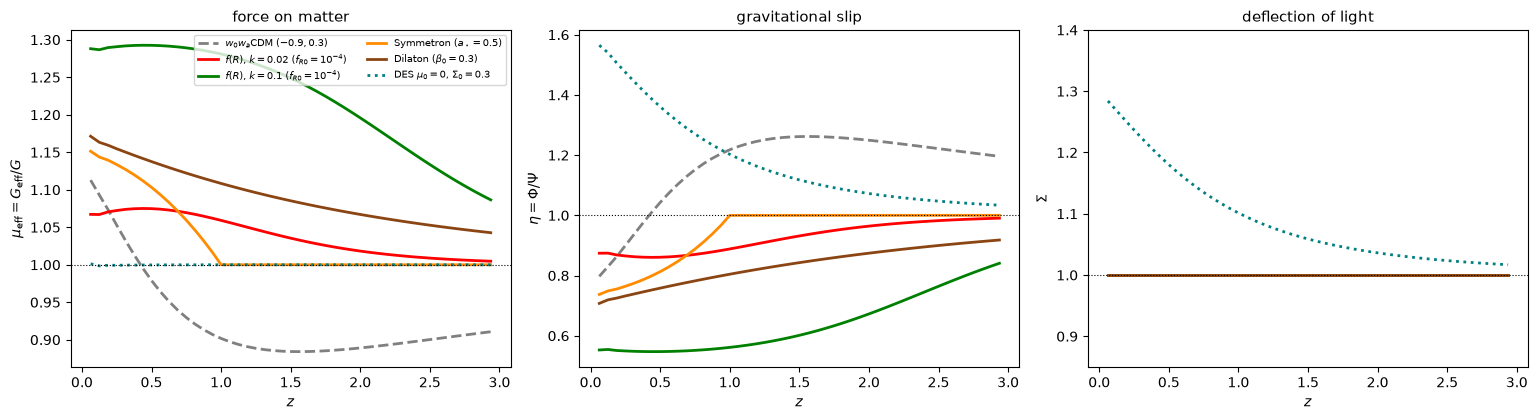

In [6]:
def Sigma(model):
    kh, zz, pW  = spectra(model, "Weyl")
    _,  _,  pD  = spectra(model, "delta_tot")
    _,  _,  pW0 = spectra(REF, "Weyl")
    _,  _,  pD0 = spectra(REF, "delta_tot")
    return kh, zz, np.sqrt((pW/pD)/(pW0/pD0))

def mu_eff(model):
    kh, zz, f, fp = growth(model)
    res = run(model)
    a = 1/(1 + zz)
    E = np.array([res.hubble_parameter(q) for q in zz])/H0
    dlnE = CubicSpline(np.log(a)[::-1], np.log(E)[::-1])(np.log(a), 1)
    Om_a = Om0*a**-3/E**2
    return kh, zz, (fp + f**2 + (2 + dlnE)[:, None]*f)/(1.5*Om_a[:, None])


c = slice(1, -1)                                   # trim spline end points
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3), sharex=True)
for m in MG_MODELS:
    kh, zz, mu = mu_eff(m)
    _,  _,  S  = Sigma(m)
    j = kof(m.kshow)
    mu_k, S_k = mu[c, j], S[c, j]
    axes[0].plot(zz[c], mu_k,            color=m.color, ls=m.ls, lw=2, label=m.name)
    axes[1].plot(zz[c], 2*S_k/mu_k - 1,  color=m.color, ls=m.ls, lw=2)
    axes[2].plot(zz[c], S_k,             color=m.color, ls=m.ls, lw=2)
for ax, lab, ttl in zip(axes, [r"$\mu_{\rm eff}=G_{\rm eff}/G$", r"$\eta=\Phi/\Psi$", r"$\Sigma$"],
                        ["force on matter", "gravitational slip", "deflection of light"]):
    ax.axhline(1, color="k", lw=0.8, ls=":"); ax.set_xlabel("$z$")
    ax.set_ylabel(lab); ax.set_title(ttl, fontsize=11)
axes[2].set_ylim(0.85, 1.4); axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("../pictures/mu_eta_Sigma_modified_gravity_MGCAMB.png", dpi=300)
plt.show()

## Growth rate $f(z)$

The direct MGCAMB counterpart of the central figure of the analytic notebook. Each curve is drawn at
the wavenumber listed in its label; the scale-independent models look the same at any $k$, the
scale-dependent ones do not - which is why $f(R)$ appears twice.

The error bars are **mock**: 2.5% on the $\Lambda$CDM curve, roughly a Stage-IV spectroscopic
survey. They are there to make the eye judge which separations are actually measurable.

Expect curves to overlap, and read that as physics rather than as a plotting failure. The DES
$\mu_0=0,\ \Sigma_0=0.3$ model sits **exactly** on $\Lambda$CDM, because $\mu_0=0$ means it changes
the deflection of light without touching the force on matter — growth cannot see it at all, and only
section 4 can. $\Lambda$CDM is drawn on top so it stays visible underneath its impostors.

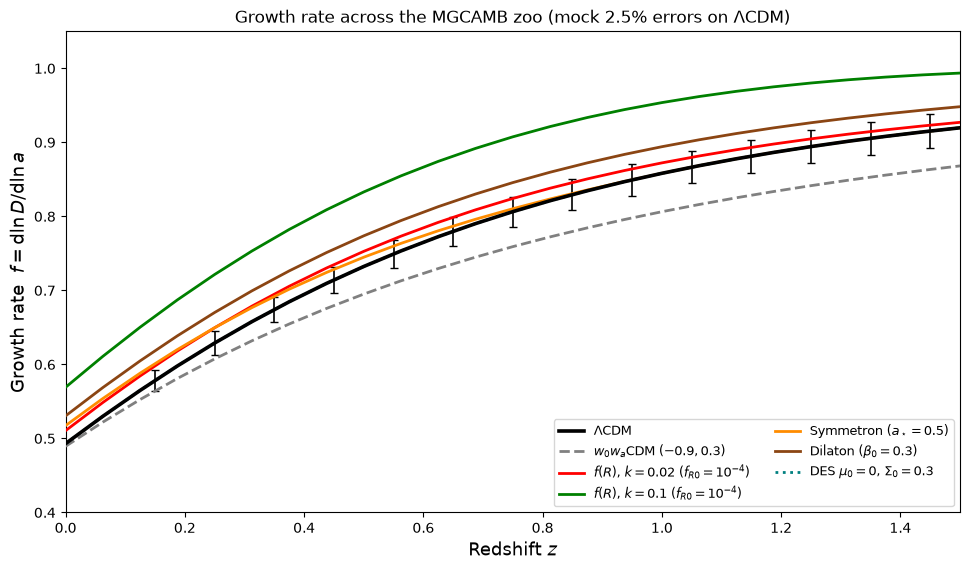

In [7]:
K_ERR = 0.1                                   # wavenumber for the mock error bars
Z_MAX = 1.5

fig, ax = plt.subplots(figsize=(9.8, 5.8))
for m in MODELS:
    kh, zz, f, _ = growth(m)
    top = (m is REF)                     # LCDM on top: several models sit exactly on it
    ax.plot(zz, f[:, kof(m.kshow)], color=m.color, ls=m.ls,
            lw=2.6 if top else 2, zorder=10 if top else 3, label=m.name)

z_d = np.arange(0.15, Z_MAX, 0.1)
f_d = np.interp(z_d, z, f_ref[:, kof(K_ERR)])
ax.errorbar(z_d, f_d, yerr=0.025*f_d, fmt="none", ecolor="black", capsize=3, lw=1.2)

# fixed frame, but never clip a model off the top
fmax = max(np.max(growth(m)[2][zz <= Z_MAX, kof(m.kshow)]) for m in MODELS)
fmin = min(np.min(growth(m)[2][zz <= Z_MAX, kof(m.kshow)]) for m in MODELS)
ax.set_xlim(0, Z_MAX); ax.set_ylim(min(0.4, fmin - 0.03), max(1.05, fmax + 0.03))
ax.set_xlabel("Redshift $z$", fontsize=13)
ax.set_ylabel(r"Growth rate  $f = \mathrm{d}\ln D/\mathrm{d}\ln a$", fontsize=13)
ax.set_title(r"Growth rate across the MGCAMB zoo (mock 2.5% errors on $\Lambda$CDM)", fontsize=12)
ax.legend(fontsize=9, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig("../pictures/growth_rate_modified_gravity_MGCAMB.png", dpi=300)
plt.show()

### The same information as a surface

The scale-dependent models are curves through a two-dimensional object. This is what the single
wavenumber above is a slice of - and it is the signature no dark-energy model can fake, since
$H(a)$ is scale-independent by homogeneity.

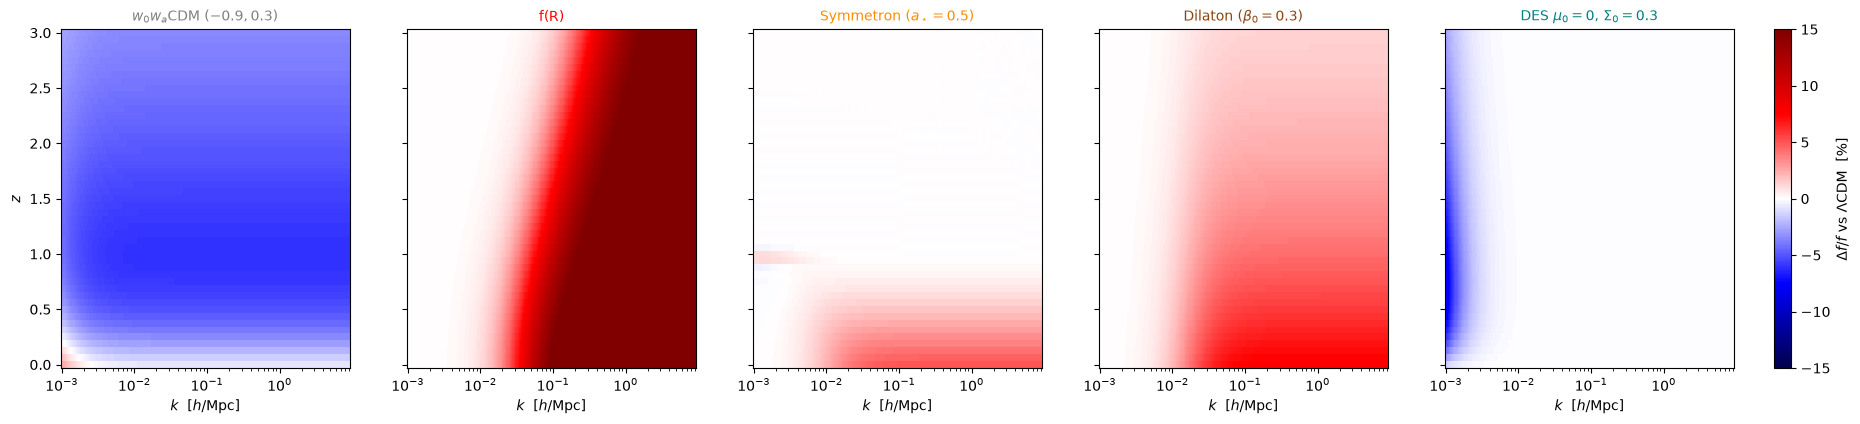

In [8]:
SURF = [m for m in MODELS if not m.name.startswith(("$f(R)$, $k=0.1")) and not m.name == r"$\Lambda$CDM"]
fig, axes = plt.subplots(1, len(SURF), figsize=(5.2*len(SURF), 4.4), sharey=True)
for ax, m in zip(np.atleast_1d(axes), SURF):
    kh, zz, f, _ = growth(m)
    im = ax.pcolormesh(kh, zz, 100*(f/f_ref - 1), shading="auto", cmap="seismic", vmin=-15, vmax=15)
    ax.set_xscale("log"); ax.set_xlabel(r"$k$  [$h$/Mpc]")
    if m.name.startswith(("$f(R)$")):
        ax.set_title("f(R)", fontsize=10, color=m.color)
    else:
         ax.set_title(m.name, fontsize=10, color=m.color)
    #ax.set_xlim(1e-2, 1.0);
np.atleast_1d(axes)[0].set_ylabel("$z$")
fig.colorbar(im, ax=axes, label=r"$\Delta f/f$ vs $\Lambda$CDM  [%]", pad=0.02)
plt.savefig("../pictures/growth_rate_modified_gravity_MGCAMB_surface.png", dpi=300)
plt.show()

## Matter power spectrum $P_k$



In [9]:
MG_MODELS

[Model(name='$w_0w_a$CDM $(-0.9,0.3)$', color='grey', mg={'MG_flag': 1, 'pure_MG_flag': 1, 'mugamma_par': 2, 'E11': 0.0, 'E22': 0.0, 'DE_model': 2, 'w0DE': -0.9, 'waDE': 0.3, 'MGDE_pert': True, 'GRtrans': 0.001}, kshow=0.1, ls='--'),
 Model(name='$f(R)$, $k=0.02$ ($f_{R0}=10^{-4}$)', color='red', mg={'MG_flag': 3, 'QSA_flag': 4, 'F_R0': 0.0001, 'FRn': 1.0, 'GRtrans': 0.001}, kshow=0.02, ls='-'),
 Model(name='$f(R)$, $k=0.1$ ($f_{R0}=10^{-4}$)', color='green', mg={'MG_flag': 3, 'QSA_flag': 4, 'F_R0': 0.0001, 'FRn': 1.0, 'GRtrans': 0.001}, kshow=0.1, ls='-'),
 Model(name='Symmetron ($a_\\star=0.5$)', color='darkorange', mg={'MG_flag': 3, 'QSA_flag': 2, 'beta_star': 0.3, 'a_star': 0.5, 'xi_star': 0.02, 'GRtrans': 0.001}, kshow=0.1, ls='-'),
 Model(name='Dilaton ($\\beta_0=0.3$)', color='saddlebrown', mg={'MG_flag': 3, 'QSA_flag': 3, 'beta0': 0.3, 'xi0': 0.02, 'DilS': 0.24, 'DilR': 1.0, 'GRtrans': 0.001}, kshow=0.1, ls='-'),
 Model(name='DES $\\mu_0=0$, $\\Sigma_0=0.3$', color='teal', mg={

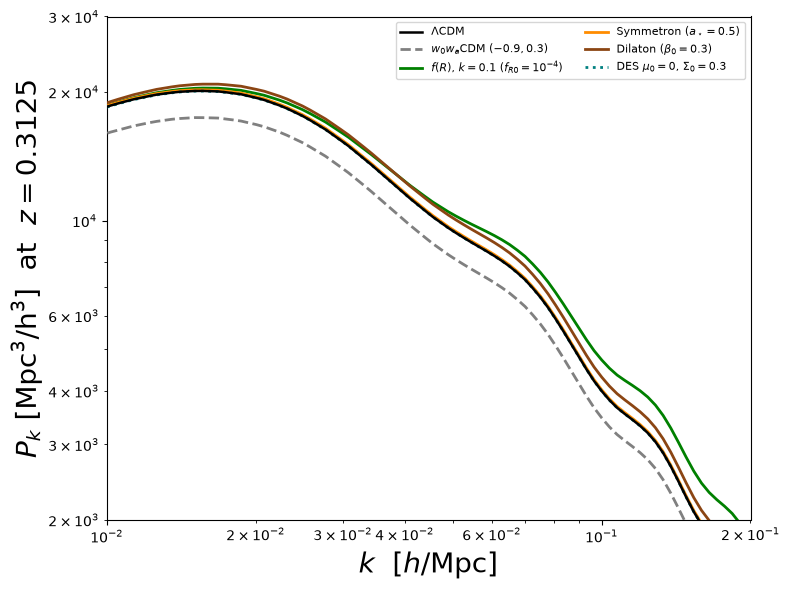

In [10]:
MODELS_PLOT = [m for m in MODELS if not m.name.startswith(("$f(R)$, $k=0.02"))]
fig, ax = plt.subplots(figsize=(8, 6))
for m in MODELS_PLOT:
    kh,  zz,  pD  = spectra(m, "delta_tot")
    top = (m is REF)
    ax.plot(kh, pD[5], color=m.color, ls=m.ls, label=m.name,lw=1.8 if top else 2, zorder=10 if top else 3)
ax.set_xlim(1e-2, 2e-1); 
ax.set_ylim(2e3, 3e4); 
ax.loglog();
ax.set_xlabel(r"$k$  [$h$/Mpc]",fontsize=20)
ax.set_ylabel(r"$P_k$ [Mpc$^{3}$/h$^{3}$]  at  $z=%s$" % zz[5],fontsize=20)
ax.legend(fontsize=8, ncol=2);
plt.tight_layout();
plt.savefig("../pictures/matter_power_modified_gravity_MGCAMB.png", dpi=300)
plt.show()

## What a survey measures: $f\sigma_8(z)$

$f$ is not an observable. Redshift-space distortions measure the amplitude of the velocity power
spectrum, $f\sigma_8(z)$, in which the galaxy bias cancels — and even that is a *compressed*
quantity. Here we use CAMB's own `get_fsigma8()`, which is the properly $8\,h^{-1}$Mpc-weighted
version.

Notice what the weighting does: it averages over $k$, and therefore **washes out most of the scale
dependence** that Figure 5 makes so obvious. That is not a defect of the plot, it is the honest
statement of how much a compressed RSD measurement can see. Recovering the $k$-dependence is exactly
what full-shape analyses are for.

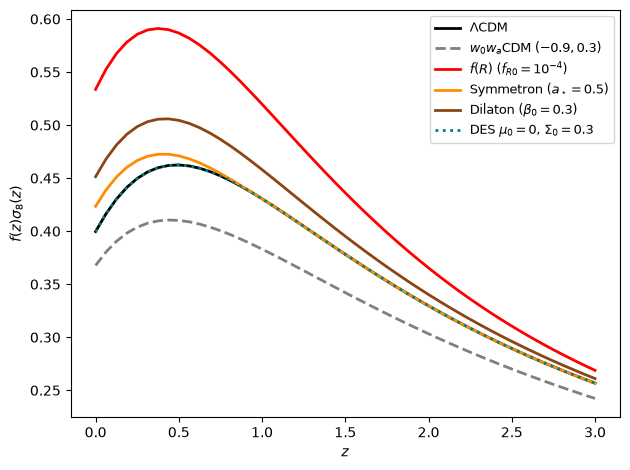

In [25]:
# CAMB's get_fsigma8() is sigma^2_vd / sigma_dd for 8 h^-1 Mpc spheres. Both sigmas are
# integrals over k against the top-hat window, so this quantity takes NO wavenumber:
# the two f(R) entries are the same CAMB run (identical `mg`, differing only in the
# plotting attribute `kshow`) and return identical arrays, one drawn invisibly under the
# other. Plot each parameter set once, and drop the k from the label -- it is not a k
# that this observable knows about. Use `growth()` if you want the k-resolved f(k, z).

plt.figure()                       # own axes: cell 18 leaves a log-log frame behind
zz, s8_ref, fs8_ref = fsigma8(REF)
plt.plot(zz, fs8_ref, color="black", lw=2, label=REF.name)
seen = set()

key  = lambda m: tuple(sorted(m.mg.items()))
mult = Counter(key(m) for m in MODELS)
     
for m in MG_MODELS:
    key = tuple(sorted(m.mg.items()))
    if key in seen:
        continue
    seen.add(key)
    _, s8, fs8 = fsigma8(m)
    plt.plot(zz, fs8, color=m.color, ls=m.ls, lw=2,
             label=re.sub(r",\s*\$k=[^$]*\$", "", m.name))
plt.xlabel("$z$")
plt.ylabel(r"$f(z)\sigma_8(z)$")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../pictures/fs8_modified_gravity_MGCAMB.png", dpi=300)
plt.show()

## $E_G$: the null test, and why it is flat here

$$E_G(z) = \frac{\Omega_{m,0}\,\Sigma(a,k)}{f(z)} \;\xrightarrow{\ \rm GR\ }\; \frac{\Omega_{m,0}}{f}$$

$E_G$ takes the ratio of lensing to velocities around the *same* galaxies, so the galaxy bias
cancels. Since $\Sigma=1$ for all three theories (§4), $E_G$ sees them **purely through $f$** — it
is not measuring their extra force directly, only the growth that force produced. A theory that
moved $\Sigma$ instead would shift $E_G$ without touching growth at all; none of our three does.

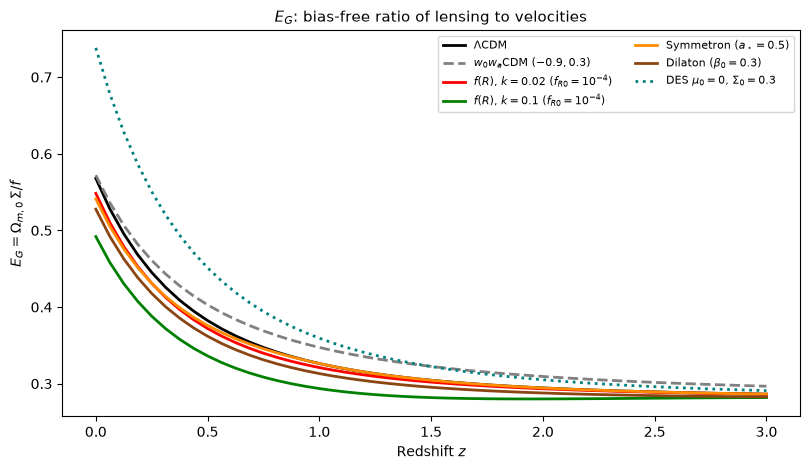

In [12]:
plt.figure(figsize=(8.2, 4.8))
plt.plot(z, Om0/f_ref[:, kof(0.1)], color="black", lw=2, label=REF.name)
for m in MG_MODELS:
    _, zz, f, _ = growth(m)
    _, _,  S    = Sigma(m)
    j = kof(m.kshow)
    plt.plot(zz, Om0*S[:, j]/f[:, j], color=m.color, ls=m.ls, lw=2, label=m.name)
plt.xlabel("Redshift $z$"); plt.ylabel(r"$E_G=\Omega_{m,0}\,\Sigma/f$")
plt.title(r"$E_G$: bias-free ratio of lensing to velocities", fontsize=11)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("../pictures/EG_modified_gravity_MGCAMB.png", dpi=300)
plt.show()


## 9. The CMB: ISW and lensing

This is what the Boltzmann code buys us over the analytic notebook.

* **Low-$\ell$ TT** carries the integrated Sachs–Wolfe effect. The lecture's relation
  $\partial_N\ln(\Phi+\Psi) = f - 1 + \partial_N\ln\Sigma$ says it all: with $\Sigma=1$ for these
  theories, a model that grows structure *faster* (larger $f$) has a *smaller* ISW signal.
* **$C_L^{\phi\phi}$** probes the Weyl potential to $z\simeq1100$. Since $\Sigma=1$, any change here
  is *indirect* — it comes only from the extra structure the modified growth produced, not from a
  modified deflection law. That is a useful thing to see explicitly.

Set `RUN_CMB = False` to skip; these are the slowest runs.

  $\Lambda$CDM                             0.8 s
  $w_0w_a$CDM $(-0.9,0.3)$                 1.8 s
  $f(R)$, $k=0.02$ ($f_{R0}=10^{-4}$)      4.1 s
  $f(R)$, $k=0.1$ ($f_{R0}=10^{-4}$)       6.3 s
  Symmetron ($a_\star=0.5$)                7.3 s
  Dilaton ($\beta_0=0.3$)                  9.6 s
  DES $\mu_0=0$, $\Sigma_0=0.3$           10.8 s


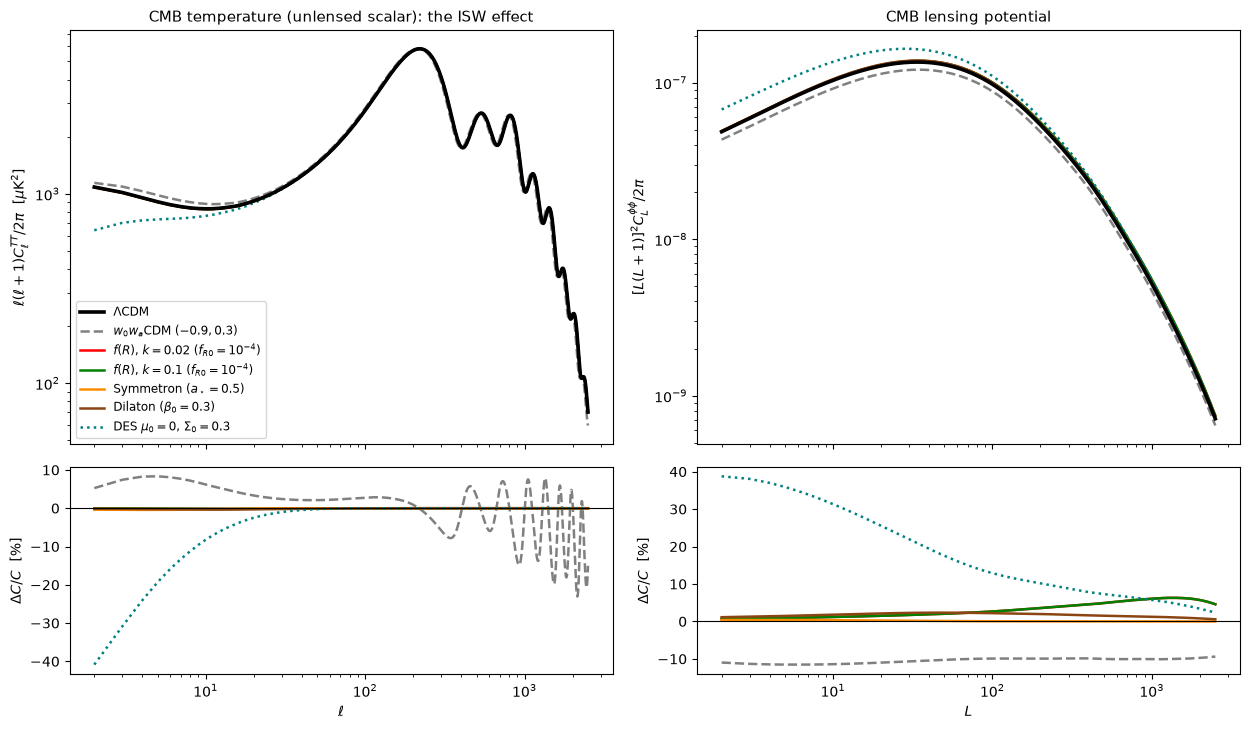

In [13]:
# ---------------------------------------------------------------------------
# CMB observables: temperature and lensing potential, for every model.
#
# Two things are what make this run at all:
#   * NonLinear_none : lens_potential_accuracy>0 switches Halofit on, and Halofit
#     is LCDM-calibrated -> NaN for every MG_flag != 0 run. That was the empty plot.
#   * unlensed scalar TT : the ISW signal is an unlensed effect, and lensing does
#     not reshape this ratio below l ~ 1000, so we drop the dependency entirely.
# ---------------------------------------------------------------------------
RUN_CMB  = True
LMAX_CMB = 2500
CMB_MODELS = MODELS
LENS_ACC = 0        # >0 makes MGCAMB return NaN for every MG_flag != 0 run

def cmb_TT_PP(model, lmax=LMAX_CMB):
    """(ell, D_ell^TT [muK^2], [L(L+1)]^2 C_L^phiphi/2pi).  None if MGCAMB fails."""
    pars = build(model, lmax=lmax + 500)
    pars.set_for_lmax(lmax + 500, lens_potential_accuracy=LENS_ACC)   # re-apply, acc=0
    pars.WantCls = pars.WantScalars = pars.Want_CMB = True
    pars.DoLensing = True
    pars.NonLinear = camb.model.NonLinear_none
    try:
        res = camb.get_results(pars)
        tt = np.asarray(res.get_unlensed_scalar_cls(lmax, CMB_unit="muK"))[:, 0]
        pp = np.asarray(res.get_lens_potential_cls(lmax))[:, 0]
    except Exception as e:
        print(f"  !! {model.name:38s} {type(e).__name__}: {e}"); return None
    if not np.isfinite(tt[2:]).all():
        print(f"  !! {model.name:38s} non-finite TT - skipped"); return None
    return np.arange(tt.size), tt, pp

_CL_CACHE = {}
def tt_pp(m):
    if m.name not in _CL_CACHE:
        _CL_CACHE[m.name] = cmb_TT_PP(m)
    return _CL_CACHE[m.name]

def rel(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    out = np.full(a.shape, np.nan)
    ok = np.isfinite(a) & np.isfinite(b) & (b != 0)
    out[ok] = 100*(a[ok]/b[ok] - 1)
    return out

if RUN_CMB:
    import time; t0 = time.time()
    for m in CMB_MODELS:
        tt_pp(m); print(f"  {m.name:38s} {time.time()-t0:5.1f} s")

    ref = tt_pp(REF)
    if ref is None:
        raise RuntimeError("LCDM reference failed - nothing to normalise against")
    ell, tt_ref, pp_ref = ref
    s = slice(2, LMAX_CMB + 1)
    x = ell[s]
    OK = [m for m in CMB_MODELS if tt_pp(m) is not None]

    # keep the phiphi panel only if the reference lensing potential is usable
    pp_ok = np.isfinite(pp_ref[2:]).all() and np.count_nonzero(pp_ref[2:]) > 100
    if not pp_ok:
        print("\n   note: lensing potential unusable at lens_potential_accuracy=0"
              " -> plotting TT only")
    SPEC = [("TT", 1, tt_ref, r"$\ell(\ell+1)C_\ell^{TT}/2\pi$  [$\mu$K$^2$]", r"$\ell$",
             "CMB temperature (unlensed scalar): the ISW effect")]
    if pp_ok:
        SPEC.append(("phi", 2, pp_ref, r"$[L(L+1)]^2C_L^{\phi\phi}/2\pi$", r"$L$",
                     "CMB lensing potential"))

    n = len(SPEC)
    fig, axes = plt.subplots(2, n, figsize=(6.3*n, 7.4), squeeze=False, sharex="col",
                             gridspec_kw=dict(height_ratios=[2, 1]))
    for col, (tag, idx, refarr, ylab, xlab, title) in enumerate(SPEC):
        top, bot = axes[0, col], axes[1, col]
        for m in OK:
            arr = tt_pp(m)[idx]; lead = (m is REF)
            top.plot(x, arr[s], color=m.color, ls=m.ls, lw=2.6 if lead else 1.8,
                     zorder=10 if lead else 3, label=m.name if col == 0 else None)
            if lead: continue
            r = rel(arr, refarr)[s]; g = np.isfinite(r)
            if not g.any():
                print(f"  !! {m.name}: {tag} residual all non-finite"); continue
            bot.plot(x[g], r[g], color=m.color, ls=m.ls, lw=1.8)
        top.set_xscale("log")
        top.set_yscale("log")
        top.set_ylabel(ylab)
        top.set_title(title, fontsize=11)
        bot.axhline(0, color="k", lw=0.8)
        bot.set_xlabel(xlab)
        bot.set_ylabel(r"$\Delta C/C$  [%]")
    axes[0, 0].legend(fontsize=8.5, loc="lower left")
    plt.tight_layout()
    plt.savefig("../pictures/cmb_TT_phiphi_modified_gravity_MGCAMB.png", dpi=300)
    plt.show()
else:
    print("skipped")